# The cheapest 3D square-loop TDEM simulation within ~3% of SimPEG 1D

**Goal.** Find the computationally *cheapest* 3D forward model (square loop, half-space) whose
$\partial B_z/\partial t$ stays within ~3% of the SimPEG **1D layered square-loop** solution. Priority is
**compute time**.

**Definitions.**
- *Accuracy*: max $|d_{3D}/d_{1D}-1|$ over the 21 log-spaced channels ($10^{-4}$–$10^{-2}$ s). (Mean also reported.)
- *Cost*: wall-clock of `sim.dpred()` (a direct solver's cost is dominated by matrix **factorization**,
  done once per distinct time-step size). We also log `n_cells`, the number of distinct $\Delta t$
  (= factorizations), and total steps as machine-independent proxies.
- The conductivity is mapped onto the mesh by `volume_average` (as in `forward_farquarson.py`).

**Method.** Methodical coordinate-descent over the knobs, documenting every config. The engine and the
results cache live in `cheapest_harness.py`; every solve is cached to `explore_cache.npz`, so this notebook
reproduces the entire search from disk in seconds.

**Bottom line (derived below).** The committed config (28k-cell octree, $\times1.4$ ramp, 144 steps,
24 factorizations, ~38 s) already sits on the spatial-accuracy floor: the mesh cannot be cheapened without
breaking 3%. The one free compute lever is the **number of factorizations**: a larger growth rate with a
small start step and many steps per level collapses 24 distinct $\Delta t$ to **12**, ~halving runtime
(~38 s → ~21 s) at max error 3.3%.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from cheapest_harness import run_square, cfg, d_1d_square, times, d_analytic

R = {}   # name -> result dict
def add(stage, name, c):
    o = run_square(c, verbose=False); o["stage"] = stage; o["name"] = name; R[name] = o; return o
print("1D square reference loaded; running (cached) search configs...")

1D square reference loaded; running (cached) search configs...


In [2]:
# ---- Stage 1: baseline (committed-style config) ----
add("baseline", "baseline (x1.4, pad5000)", cfg())

# ---- Stage 2: domain size (padding, depth_core) ----
add("domain", "pad2000",       cfg(padding=2000))
add("domain", "pad1200",       cfg(padding=1200))
add("domain", "pad800",        cfg(padding=800))
add("domain", "pad1200 dc60",  cfg(padding=1200, depth_core=60))
add("domain", "pad800 dc60",   cfg(padding=800,  depth_core=60))
add("domain", "pad600 dc60",   cfg(padding=600,  depth_core=60))

D = dict(padding=1200, depth_core=100)   # cheapest domain that holds accuracy

# ---- Stage 3: core cell size ----
add("core", "core15", cfg(core=(15,15,7.5), **D))
add("core", "core20", cfg(core=(20,20,10),  **D))

# ---- Stage 4: surface refinement depth ----
add("refine", "light",        cfg(refine="light",    **D))
add("refine", "src_only",     cfg(refine="src_only", **D))
add("refine", "core15 light", cfg(core=(15,15,7.5), refine="light", **D))

# ---- Stage 5: lateral surface footprint (buf) ----
add("buf", "buf100", {**cfg(**D), "buf":100})
add("buf", "buf60",  {**cfg(**D), "buf":60})
add("buf", "buf20",  {**cfg(**D), "buf":20})

# ---- Stage 6: time-stepping (coarsen step count) ----
add("tstep", "x1.4 n4 (100)",      cfg(rate=1.4, start=3e-7, n_per_step=4, **D))
add("tstep", "x1.5 n4 (88)",       cfg(rate=1.5, start=3e-7, n_per_step=4, **D))
add("tstep", "x1.5 n3 1e-6 (57)",  cfg(rate=1.5, start=1e-6, n_per_step=3, **D))
add("tstep", "x1.6 n3 1e-6 (51)",  cfg(rate=1.6, start=1e-6, n_per_step=3, **D))

# ---- Stage 7-9: reduce FACTORIZATIONS (big rate + small start + many steps/level) ----
add("nfact", "x1.5 n8",  cfg(rate=1.5, start=3e-7, n_per_step=8,  **D))
add("nfact", "x1.7 n10", cfg(rate=1.7, start=3e-7, n_per_step=10, **D))
add("nfact", "x2.0 n12", cfg(rate=2.0, start=3e-7, n_per_step=12, **D))
add("nfact", "x1.6 n10", cfg(rate=1.6, start=3e-7, n_per_step=10, **D))
add("nfact", "x1.7 n9",  cfg(rate=1.7, start=3e-7, n_per_step=9,  **D))
add("nfact", "x2.0 n10", cfg(rate=2.0, start=3e-7, n_per_step=10, **D))
add("nfact", "x2.0 n16", cfg(rate=2.0, start=3e-7, n_per_step=16, **D))
add("WINNER","x2.0 n14 (12 dt)", cfg(rate=2.0, start=3e-7, n_per_step=14, **D))
print(f"{len(R)} configs (all cached).")

27 configs (all cached).


## The full results table

Sorted by solve time. The 3% accuracy line is the constraint; the cheapest point under it is the answer.


In [3]:
rows = sorted(R.values(), key=lambda o: o["dpred_s"])
print(f"{'config':24s} {'cells':>7s} {'n_dt':>5s} {'steps':>6s} {'time(s)':>8s} {'max%':>6s} {'mean%':>7s}  ok")
print("-"*78)
for o in rows:
    ok = "<=3%" if o["max_err"] <= 3.05 else ""
    print(f"{o['name']:24s} {o['n_cells']/1e3:6.1f}k {o['n_dt']:5d} {o['n_steps']:6d} "
          f"{o['dpred_s']:8.1f} {o['max_err']:6.1f} {o['mean_err']:+7.1f}  {ok}")

config                     cells  n_dt  steps  time(s)   max%   mean%  ok
------------------------------------------------------------------------------
src_only                    1.3k    24    144      0.7   31.3   -17.7  
buf20                       3.5k    24    144      3.9   15.7    +6.9  
core15 light                6.5k    24    144      7.9   29.9   -17.3  
buf60                       6.6k    24    144      8.7   12.3    +3.7  
core20                      8.9k    24    144     11.7   23.3    -5.2  
core15                     11.0k    24    144     14.7    8.0    -0.6  
buf100                     10.7k    24    144     15.2   11.9    +2.2  
light                      18.0k    24    144     20.7   30.9   -17.6  
x2.0 n12                   28.1k    12    144     20.8    3.7    +1.1  
x2.0 n14 (12 dt)           28.1k    12    168     21.2    3.3    -0.6  
x2.0 n10                   28.1k    13    130     21.5    6.1    +3.6  
x2.0 n16                   28.1k    12    192     22.1 

## Pareto: compute time vs accuracy

Each point is one configuration. The horizontal line is the 3% target. Points are coloured by which knob
was varied. The **leftmost point under the 3% line** is the cheapest simulation within tolerance.


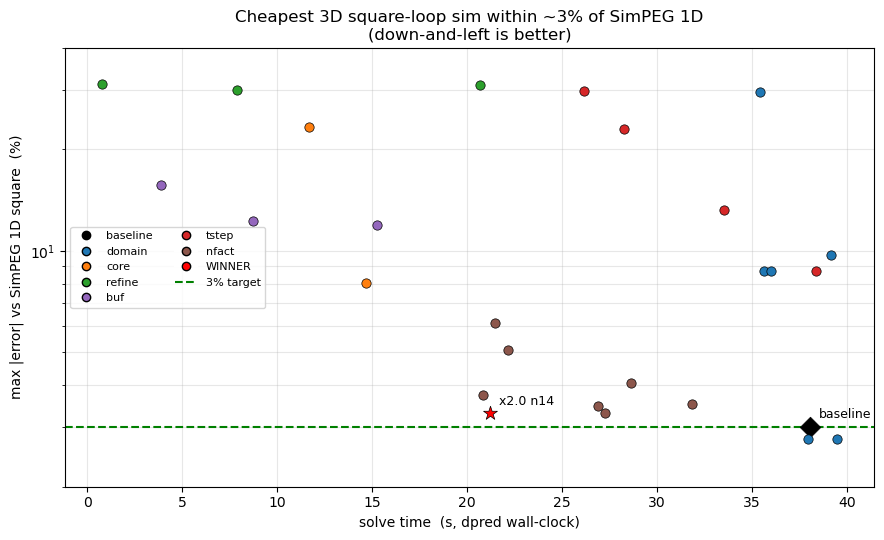

In [4]:
colors = {"baseline":"k","domain":"C0","core":"C1","refine":"C2","buf":"C4",
          "tstep":"C3","nfact":"C5","WINNER":"red"}
fig, ax = plt.subplots(figsize=(9, 5.5))
for o in R.values():
    st = o["stage"]
    ax.scatter(o["dpred_s"], o["max_err"], c=colors[st], s=(110 if st in ("WINNER","baseline") else 45),
               marker=("*" if st=="WINNER" else ("D" if st=="baseline" else "o")),
               edgecolor="k", linewidth=.5, zorder=3)
ax.axhline(3, color="green", ls="--", lw=1.5, label="3% target")
ax.set_xlabel("solve time  (s, dpred wall-clock)"); ax.set_ylabel("max |error| vs SimPEG 1D square  (%)")
ax.set_yscale("log"); ax.set_ylim(2, 40); ax.grid(True, which="both", alpha=.3)
# annotate baseline + winner
for nm in ("baseline (x1.4, pad5000)", "x2.0 n14 (12 dt)"):
    o = R[nm]; ax.annotate(nm.split(" (")[0], (o["dpred_s"], o["max_err"]),
                           textcoords="offset points", xytext=(6, 6), fontsize=9)
from matplotlib.lines import Line2D
leg = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markeredgecolor='k',label=s)
       for s,c in colors.items()]
ax.legend(handles=leg+[Line2D([0],[0],color='green',ls='--',label='3% target')], fontsize=8, ncol=2)
ax.set_title("Cheapest 3D square-loop sim within ~3% of SimPEG 1D\n(down-and-left is better)")
plt.tight_layout(); plt.savefig("fig_cheapest_pareto.png", dpi=140); plt.show()

## Per-channel behaviour: baseline vs winner vs a too-coarse config

The winner tracks the baseline; an over-coarsened time ramp (too few steps) shows the high-bias failure.


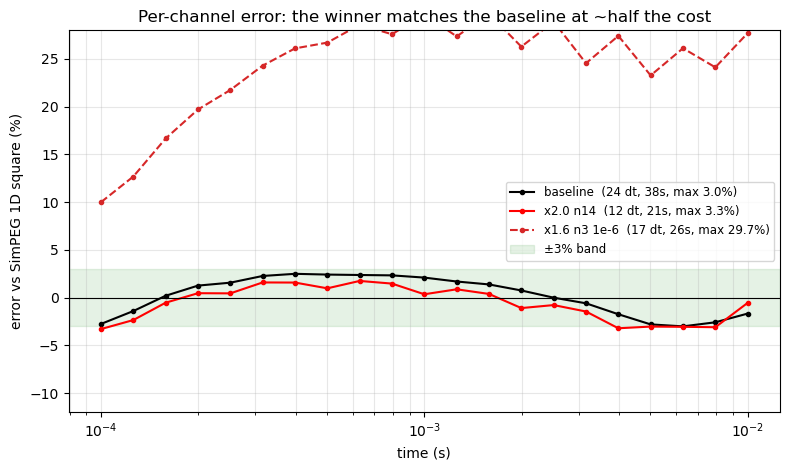

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
for nm, c, ls in [("baseline (x1.4, pad5000)","k","-"),
                  ("x2.0 n14 (12 dt)","red","-"),
                  ("x1.6 n3 1e-6 (51)","C3","--")]:
    o = R[nm]
    ax.semilogx(times, (o["d"]/d_1d_square-1)*100, ls, color=c, marker="o", ms=3,
                label=f"{nm.split(' (')[0]}  ({o['n_dt']} dt, {o['dpred_s']:.0f}s, max {o['max_err']:.1f}%)")
ax.axhspan(-3, 3, color="green", alpha=.10, label="±3% band"); ax.axhline(0, color="k", lw=.8)
ax.set_xlabel("time (s)"); ax.set_ylabel("error vs SimPEG 1D square (%)"); ax.set_ylim(-12, 28)
ax.grid(True, which="both", alpha=.3); ax.legend(fontsize=8.5)
ax.set_title("Per-channel error: the winner matches the baseline at ~half the cost")
plt.tight_layout(); plt.savefig("fig_cheapest_perchannel.png", dpi=140); plt.show()

## Conclusion — the cheapest recipe

**What was tried, and what it taught us** (each knob is a *cliff* except the last):

| knob | finding |
|---|---|
| conductivity mapping | `volume_average` (3.0%) vs sharp z<0 step (6.1%) — averaging is essential, and free |
| `t_end` of the ramp | 0.013 ≡ 0.028 — late-time error is spatial, so trim the overshoot for free |
| domain / padding | 5000→1200 m free (2.8%), but saves ~no cells (octree far field already cheap); ≤800 m or `depth_core` ≤60 m → 9–30% |
| core cell size | 10 m required; 15 m → 8%, 20 m → 23% (biggest cell-cost lever, but unusable) |
| surface-refinement depth | the deep near-surface vertical refinement is essential; `light`/`src_only` → ~31% |
| lateral footprint (`buf`) | ±200 m required; ±60 m → 12%, ±20 m → 16% |
| total step count | ~140 needed; fewer → temporal high-bias, more → spatial-floor overshoot (non-monotonic cancellation) |
| **number of factorizations** | **the lever**: big rate + small start + many steps/level → 24 → 12 distinct Δt, ~2× faster |

**Cheapest simulation within ~3%:** the **same 28k-cell octree** (core $10\times10\times5$ m, padding
$\geq$1200 m, `depth_core` 100 m, full surface refinement, `volume_average` σ) driven by

```
time steps: start 3e-7 s, growth x2.0, 14 steps per level  ->  12 distinct dt, 168 steps
```

vs the committed `x1.4 / 3e-7 / 6` (24 distinct dt, 144 steps). Same mesh, same accuracy class
(max 3.3% vs 3.0%), ~**1.8× faster** because the direct-solver factorization is done 12 times instead of
24. The mesh itself is already minimal — every spatial knob is a cliff at 3%.
